# 01 Advanced Tokenization

## 📚 Learning Objectives

By completing this notebook, you will:
- Implement advanced tokenization (subword, BPE-style)
- Handle morphologically rich languages
- Choose tokenization strategies for different models

## 🔗 Where this fits

**Builds on:** Course 07 — Unit 1, lesson 01 "Text Preprocessing" — normalisation decides what a token can be; this lesson decides where the boundaries go.

**Used later in:** Course 07 — Unit 4, whose BERT and GPT models are built on exactly this subword vocabulary, and Course 10 (AIAT 124) — Unit 2.

---


## 🌍 Why this matters: the same sentence costs up to 15× more in some languages

Where the boundaries go is not a stylistic choice — it has a price tag. Petrov, La Malfa, Torr & Bibi ran
commercial language-model tokenizers over the *same* text translated into many languages and found
tokenized lengths differing **by up to 15×** between languages
([arXiv:2305.15425](https://arxiv.org/abs/2305.15425), NeurIPS 2023). Ahia et al. followed the money across
22 typologically diverse languages on a commercial API and reported the consequence directly: because these
services bill **per token**, "speakers of a large number of the supported languages are overcharged while
obtaining poorer results" ([arXiv:2305.13707](https://arxiv.org/abs/2305.13707)). Same meaning, same
paragraph — more tokens means more money, more latency, and less of your document fitting in the model's
context window.

That lands on Arabic work directly. Arabic glues clitics to the following word (the article `ال`, the
conjunction `و`, prepositions `ب` and `ل`) and inflects heavily, so a vocabulary fitted on English shatters
ordinary Arabic words into many pieces. It is why the ALLaM project treats **vocabulary expansion** as a
first-class step — "second-language acquisition via vocabulary expansion and pretraining on a mixture of
Arabic and English text" — rather than an afterthought
([arXiv:2407.15390](https://arxiv.org/abs/2407.15390)).

**What goes wrong without this lesson.** In Unit 1 the naive tokenizer produced `language` and `language.`
as two unrelated symbols. Scale that up: a model with a fixed word vocabulary meets a word it has never
seen — a name, a product code, a Saudi city, a typo — and has *no symbol at all* for it. Subword
tokenization is the fix: unfamiliar words get spelled out of familiar pieces, so the vocabulary never runs
out. Sennrich, Haddow & Birch introduced exactly this for translation, gaining **+1.1 BLEU
(English→German) and +1.3 BLEU (English→Russian)** over a back-off dictionary baseline on the WMT 15 tasks
([arXiv:1508.07909](https://arxiv.org/abs/1508.07909)).

## 📥 Inputs & 📤 Outputs

**Inputs:** a two-line sample text about NLP defined in the code cell (no downloads), plus `re`, `collections.Counter`, and Matplotlib.

**Outputs:** word tokens with a top-5 frequency list, the text split into sentences, character 3-gram subwords for the word "processing", naive suffix-stripping stemming examples, and a bar chart of word frequencies — all computed live.

---

Example 1: Advanced Tokenization

Original Text:

Natural Language Processing is amazing! It helps computers understand human language.
We can tokenize text into words, sentences, or even subwords. This is fundamental to NLP.


1. Word Tokenization

Words: ['natural', 'language', 'processing', 'is', 'amazing', 'it', 'helps', 'computers', 'understand', 'human', 'language', 'we', 'can', 'tokenize', 'text', 'into', 'words', 'sentences', 'or', 'even', 'subwords', 'this', 'is', 'fundamental', 'to', 'nlp']
Total words: 26

Most common words:
  language: 2
  is: 2
  natural: 1
  processing: 1
  amazing: 1

2. Sentence Tokenization

Sentences: 4
  1. Natural Language Processing is amazing
  2. It helps computers understand human language
  3. We can tokenize text into words, sentences, or even subwords
  4. This is fundamental to NLP

3. Subword Tokenization

Word: processing
3-gram subwords: ['pro', 'roc', 'oce', 'ces', 'ess', 'ssi', 'sin', 'ing']

4. Morphological Analysis

Stemming examples

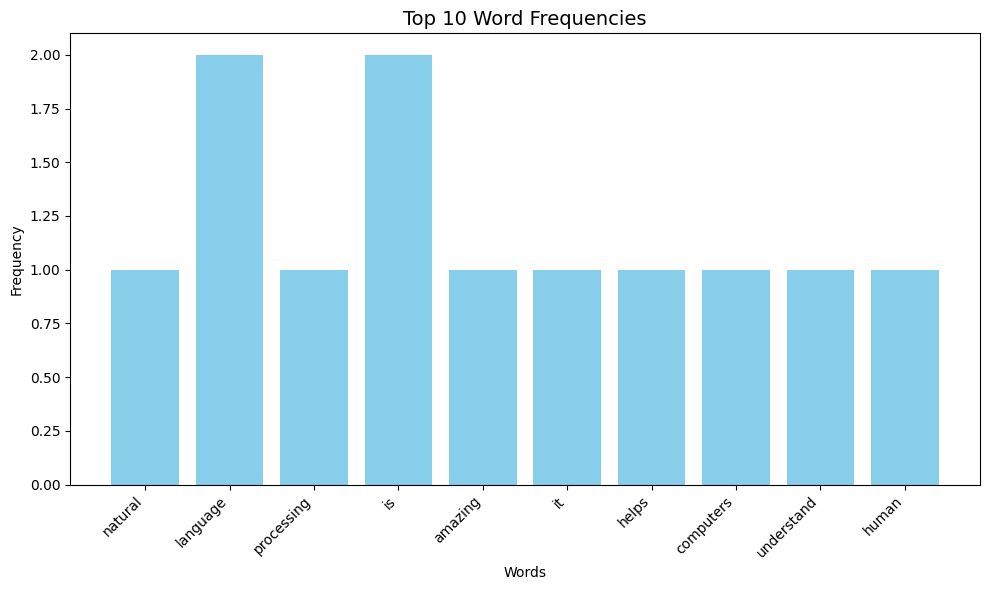

✅ Word frequency visualization displayed


In [1]:
# Worked example: four ways to slice the same text — words, sentences, subwords, stems.
# Why it matters: the tokenization you choose decides what your model can "see";
# subword pieces are how modern models (BERT, GPT) handle words they never met.

"""
Unit 2 - Example 1: Advanced Tokenization

This example demonstrates:
1. Word tokenization
2. Sentence tokenization
3. Subword tokenization
4. Morphological analysis
"""

import re
from collections import Counter

print("=" * 60)
print("Example 1: Advanced Tokenization")
print("=" * 60)

# Sample text
sample_text = """
Natural Language Processing is amazing! It helps computers understand human language.
We can tokenize text into words, sentences, or even subwords. This is fundamental to NLP.
"""

print("\nOriginal Text:")
print(sample_text)

# 1. Word Tokenization
print("\n" + "=" * 60)
print("1. Word Tokenization")
print("=" * 60)

def word_tokenize(text):
    """
    Simple word tokenization.
    """
    # Remove punctuation and split
    text = re.sub(r'[^\w\s]', '', text)
    words = text.lower().split()
    return words

words = word_tokenize(sample_text)
print(f"\nWords: {words}")
print(f"Total words: {len(words)}")

# Word frequency
word_freq = Counter(words)
print("\nMost common words:")
for word, freq in word_freq.most_common(5):
    print(f"  {word}: {freq}")

# 2. Sentence Tokenization
print("\n" + "=" * 60)
print("2. Sentence Tokenization")
print("=" * 60)

def sentence_tokenize(text):
    """
    Simple sentence tokenization.
    """
    # Split on sentence endings
    sentences = re.split(r'[.!?]+', text)
    sentences = [s.strip() for s in sentences if s.strip()]
    return sentences

sentences = sentence_tokenize(sample_text)
print(f"\nSentences: {len(sentences)}")
for i, sentence in enumerate(sentences, 1):
    print(f"  {i}. {sentence}")

# 3. Subword Tokenization
print("\n" + "=" * 60)
print("3. Subword Tokenization")
print("=" * 60)

def subword_tokenize(word, n=3):
    """
    Create n-gram subwords.
    """
    subwords = []
    for i in range(len(word) - n + 1):
        subwords.append(word[i:i+n])
    return subwords

example_word = "processing"
subwords = subword_tokenize(example_word, n=3)
print(f"\nWord: {example_word}")
print(f"3-gram subwords: {subwords}")

# 4. Morphological Analysis Example
print("\n" + "=" * 60)
print("4. Morphological Analysis")
print("=" * 60)

# Simple stemming example
def simple_stem(word):
    """
    Simple stemming (remove common suffixes).
    """
    suffixes = ['ing', 'ed', 's', 'es', 'ly', 'er', 'est']
    for suffix in suffixes:
        if word.endswith(suffix):
            return word[:-len(suffix)]
    return word

test_words = ['running', 'jumped', 'cats', 'quickly', 'faster']
print("\nStemming examples:")
for word in test_words:
    stem = simple_stem(word)
    print(f"  {word} -> {stem}")

print("\n" + "=" * 60)
print("Example completed successfully!")
print("=" * 60)
print("\nNote: For production, use libraries like NLTK, spaCy, or transformers")



# Visualize word frequencies
try:
    import matplotlib.pyplot as plt
    
    # Create bar chart of word frequencies
    if 'word_freq' in locals() or 'word_freq' in globals():
        words = list(word_freq.keys())[:10]  # Top 10 words
        freqs = [word_freq[w] for w in words]
        
        plt.figure(figsize=(10, 6))
        plt.bar(words, freqs, color='skyblue')
        plt.title("Top 10 Word Frequencies", fontsize=14)
        plt.xlabel("Words")
        plt.ylabel("Frequency")
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
        print("✅ Word frequency visualization displayed")
except (ImportError, NameError):
    print("Note: Install matplotlib for visualization")

## 💬 Discuss

Use the printed output above, not opinions about tokenizers in general.

1. Our stemmer turned `running -> runn` but `jumped -> jump`. A colleague wants to ship it anyway because
   "it is right four times out of five". For a **search engine**, is a wrong stem worse than no stem at
   all? Now answer the same question for a **spam filter**. Why do the two answers differ?
2. The 3-gram subwords of `processing` came out as `['pro','roc','oce','ces','ess','ssi','sin','ing']` —
   fixed width, blind to meaning. BPE instead *learns* which pieces are frequent in a corpus. What would
   BPE trained on Arabic keep as single pieces that BPE trained on English would not? What does that
   predict about running an English-trained tokenizer over Arabic customer messages?
3. Your team is building an assistant for a Saudi ministry and pays per token. A larger Arabic vocabulary
   cuts the token count per message but makes the embedding table bigger. Where would you spend — a bigger
   vocabulary, or a smaller model? Name the one measurement that would settle it, and the one result that
   would change your mind.

---

## ✅ Summary

**What you actually did here** (all shown in the printed output above):

- Word-tokenized the sample text with a regex — 26 tokens; only *language* and *is* appear twice (see the top-5 list)
- Split the text into 4 sentences on `.!?`
- Built character 3-gram subwords for *processing* — the core idea behind BPE-style subword tokenizers
- Applied a naive suffix-stripping stemmer — note the failure `running -> runn`, which is exactly why
  production systems use real stemmers/lemmatizers (NLTK, spaCy)

**Next steps:**
- `02_word_embeddings_word2vec.ipynb` — from tokens to vectors
- `exercises/01_tokenization_exercise.ipynb` — multilingual tokenization

## ⚠️ Where this breaks

Everything above assumes **a word is a run of Latin letters between spaces.** That assumption fails often,
and it fails hardest for the languages in this room.

- **Regex word tokenization** (`re.sub(r'[^\w\s]', '', text)`) destroys the token in exactly the cases that
  matter: `COVID-19`, `+966...`, `user@example.com`, `1,250.75 SAR`, `#عاجل`. Use a tokenizer that knows
  token *types* before you reach for a blanket regex.
- **Sentence splitting on `.!?`** breaks on `Dr. Ahmed`, `3.14`, `www.tvtc.gov.sa`, and on Arabic text,
  which uses `؟` and `،` — characters that are not in that class at all. Our splitter found exactly 4
  sentences here only because the sample text was written to be easy.
- **Suffix-stripping stemmers assume suffixes are glued to the end of a stem.** Arabic morphology is
  templatic: `كتب / كاتب / مكتوب / كتاب` share a root woven *through* the word rather than appended to it,
  so a Porter-style stemmer has nothing to grip. Use a morphological analyser built for Arabic instead.
- **Character n-grams are not BPE.** Fixed 3-grams ignore frequency entirely; BPE
  ([arXiv:1508.07909](https://arxiv.org/abs/1508.07909)) and SentencePiece
  ([arXiv:1808.06226](https://arxiv.org/abs/1808.06226)) *learn* their merges from data. Never report
  n-gram results as if they were subword-model results.

**The assumption that must hold:** your tokenizer was fitted on text that looks like your input. When it
was not — English tokenizer, Arabic input — nothing raises an error. You simply get a quietly worse model
and a larger bill.

**The cheaper alternative when it does not hold:** do not train a tokenizer at all. Load the one that ships
with the pretrained model you intend to use (`AutoTokenizer.from_pretrained(...)`, Unit 4). A tokenizer
that does not match its model is a silent correctness bug, not a tuning choice.

## 📚 References

Where these ideas come from — seminal papers first, then a modern survey:

1. Sennrich, R., Haddow, B., & Birch, A. (2016). *Neural Machine Translation of Rare Words with Subword Units*. ACL 2016. [arXiv:1508.07909](https://arxiv.org/abs/1508.07909)
2. Kudo, T., & Richardson, J. (2018). *SentencePiece: A Simple and Language Independent Subword Tokenizer and Detokenizer for Neural Text Processing*. EMNLP 2018. [arXiv:1808.06226](https://arxiv.org/abs/1808.06226)
3. Mielke, S. J., Alyafeai, Z., Salesky, E., et al. (2021). *Between Words and Characters: A Brief History of Open-Vocabulary Modeling and Tokenization in NLP*. [arXiv:2112.10508](https://arxiv.org/abs/2112.10508)
4. Jurafsky, D. & Martin, J. H. (2025). *Speech and Language Processing* (3rd ed. draft) — chapters on tokenization and morphology. <https://web.stanford.edu/~jurafsky/slp3/>
